# 06 - Batch Gauge Signal Strength

For every LGA with quality-verified upstream gauges, compute the best Spearman r
and best lag between each gauge's streamflow (Google GRRR reanalysis) and the
LGA's Floodscan SFED, restricted to wet-season months (July–November).

**Inputs (from Azure):**
- `ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas.parquet`
- `ds-aa-nga-flooding/processed/sel_lga_upstream_gauges.parquet`
- Google GRRR reanalysis zarr (public GCS bucket)

**Output (saved to Azure):**
- `ds-aa-nga-flooding/processed/gauge_lga_correlations.parquet`
  Columns: `lga_pcode`, `lga_name`, `gauge_id`, `river`, `hop_distance`, `best_r`, `best_lag`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ocha_stratus as stratus
from dotenv import load_dotenv
from tqdm.notebook import tqdm

from src.datasources import grrr

load_dotenv()

True

## Parameters

In [3]:
MIN_LAG = -5
MAX_LAG = 30
FLOOD_SEASON_MONTHS = [7, 8, 9, 10, 11]  # July–November
MIN_OBS = 30  # Minimum wet-season observations required

lags = list(range(MIN_LAG, MAX_LAG + 1))

## Load data

In [4]:
# Floodscan - SFED band only
df_fs_all = stratus.load_parquet_from_blob(
    "ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas.parquet"
)
df_fs = df_fs_all[df_fs_all["band"] == "SFED"].copy()
df_fs["valid_date"] = pd.to_datetime(df_fs["valid_date"])

# Upstream gauge relationships - quality-verified only
df_upstream_all = stratus.load_parquet_from_blob(
    "ds-aa-nga-flooding/processed/sel_lga_upstream_gauges.parquet"
)
df_upstream = df_upstream_all[df_upstream_all["quality_verified"] == True].copy()

# LGAs with both QV upstream gauges and Floodscan coverage
lgas_both = sorted(set(df_upstream["lga_pcode"]) & set(df_fs["pcode"]))
df_upstream = df_upstream[df_upstream["lga_pcode"].isin(lgas_both)].copy()

print(f"Floodscan: {df_fs['pcode'].nunique()} LGAs, {df_fs.valid_date.min().date()} – {df_fs.valid_date.max().date()}")
print(f"LGAs with QV gauges + Floodscan: {len(lgas_both)}")
print(f"Total QV gauge-LGA pairs: {len(df_upstream)}")

Floodscan: 42 LGAs, 1998-01-12 – 2026-02-15
LGAs with QV gauges + Floodscan: 23
Total QV gauge-LGA pairs: 294


## Batch load reanalysis

Load reanalysis streamflow for all unique quality-verified gauges in one call.

In [5]:
all_gauge_ids = df_upstream["gauge_id"].unique().tolist()
print(f"Loading reanalysis for {len(all_gauge_ids)} unique QV gauges...")

ds_ra = grrr.load_reanalysis(gauge=all_gauge_ids)
df_ra = grrr.process_reanalysis(ds_ra)
df_ra["valid_date"] = df_ra["valid_time"].dt.normalize()

print(f"Reanalysis loaded: {df_ra.valid_date.min().date()} – {df_ra.valid_date.max().date()}")
print(f"Shape: {df_ra.shape}")

Loading reanalysis for 21 unique QV gauges...
Reanalysis loaded: 1980-01-01 – 2023-12-23
Shape: (337323, 4)


## Batch correlation computation

For each LGA-gauge pair:
1. Merge gauge streamflow with LGA Floodscan SFED
2. Restrict to wet-season months
3. Compute Spearman r at each lag (wet season data only)
4. Record best lag and corresponding r

In [6]:
results = []

for lga_pcode in tqdm(lgas_both, desc="LGAs"):
    lga_name = df_upstream[df_upstream["lga_pcode"] == lga_pcode]["lga_name"].iloc[0]
    df_lga_up = df_upstream[df_upstream["lga_pcode"] == lga_pcode].copy()

    # SFED for this LGA
    df_sfed_lga = (
        df_fs[df_fs["pcode"] == lga_pcode][["valid_date", "mean"]]
        .rename(columns={"mean": "sfed"})
    )

    for _, gauge_row in df_lga_up.iterrows():
        gauge_id = gauge_row["gauge_id"]
        river = gauge_row.get("gauge_river", "Unknown")
        hop = gauge_row.get("hop_distance", None)

        df_g = df_ra[df_ra["gauge_id"] == gauge_id][["valid_date", "streamflow"]].copy()

        df_merged = (
            df_sfed_lga.merge(df_g, on="valid_date", how="inner")
            .sort_values("valid_date")
            .reset_index(drop=True)
        )
        df_merged = df_merged[df_merged["valid_date"].dt.month.isin(FLOOD_SEASON_MONTHS)]

        if len(df_merged) < MIN_OBS:
            continue

        corr_at_lag = [
            df_merged["sfed"].corr(df_merged["streamflow"].shift(lag), method="spearman")
            for lag in lags
        ]

        best_idx = int(np.argmax(corr_at_lag))
        best_r = float(corr_at_lag[best_idx])
        best_lag = lags[best_idx]

        results.append({
            "lga_pcode": lga_pcode,
            "lga_name": lga_name,
            "gauge_id": gauge_id,
            "river": river,
            "hop_distance": hop,
            "best_r": best_r,
            "best_lag": best_lag,
        })

df_corr_all = pd.DataFrame(results)
print(f"Computed correlations for {len(df_corr_all)} LGA-gauge pairs")
print(f"Across {df_corr_all['lga_pcode'].nunique()} LGAs and {df_corr_all['gauge_id'].nunique()} unique gauges")

LGAs:   0%|          | 0/23 [00:00<?, ?it/s]

Computed correlations for 294 LGA-gauge pairs
Across 23 LGAs and 21 unique gauges


## Summary

In [7]:
print("Best r distribution:")
print(df_corr_all["best_r"].describe().round(3))
print("\nBest lag distribution:")
print(df_corr_all["best_lag"].describe().round(1))

# Best gauge per LGA
df_best_per_lga = (
    df_corr_all.sort_values("best_r", ascending=False)
    .groupby(["lga_pcode", "lga_name"])
    .first()
    .reset_index()[["lga_pcode", "lga_name", "gauge_id", "river", "best_r", "best_lag", "hop_distance"]]
    .sort_values("best_r", ascending=False)
    .reset_index(drop=True)
)
print("\nBest gauge per LGA (by Spearman r):")
df_best_per_lga

Best r distribution:
count    294.000
mean       0.640
std        0.173
min        0.085
25%        0.603
50%        0.694
75%        0.752
max        0.798
Name: best_r, dtype: float64

Best lag distribution:
count    294.0
mean       9.6
std       11.1
min       -5.0
25%        0.0
50%       11.0
75%       18.0
max       30.0
Name: best_lag, dtype: float64

Best gauge per LGA (by Spearman r):


,lga_pcode,lga_name,gauge_id,river,best_r,best_lag,hop_distance
0,NG023004,Bassa,hybas_1120842550,Benue,0.798100,14,79
1,NG035006,Ibi,hybas_1120842550,Benue,0.790056,-1,37
2,NG023011,Kogi,hybas_1120842550,Benue,0.785080,14,85
3,NG012005,Esan South East,hybas_1120872430,Benue,0.784227,13,61
4,NG006007,Southern Ijaw,hybas_1120842550,Benue,0.783069,23,120
5,NG006006,Sagbama,hybas_1120842550,Benue,0.769600,22,115
6,NG023006,Ibaji,hybas_1120842550,Benue,0.767218,19,98
7,NG006003,Kolokuma/Opokuma,hybas_1120842550,Benue,0.767086,23,117
8,NG012008,Etsako East,hybas_1120842550,Benue,0.763109,15,95
9,NG026012,Toto,hybas_1120842550,Benue,0.757899,11,79


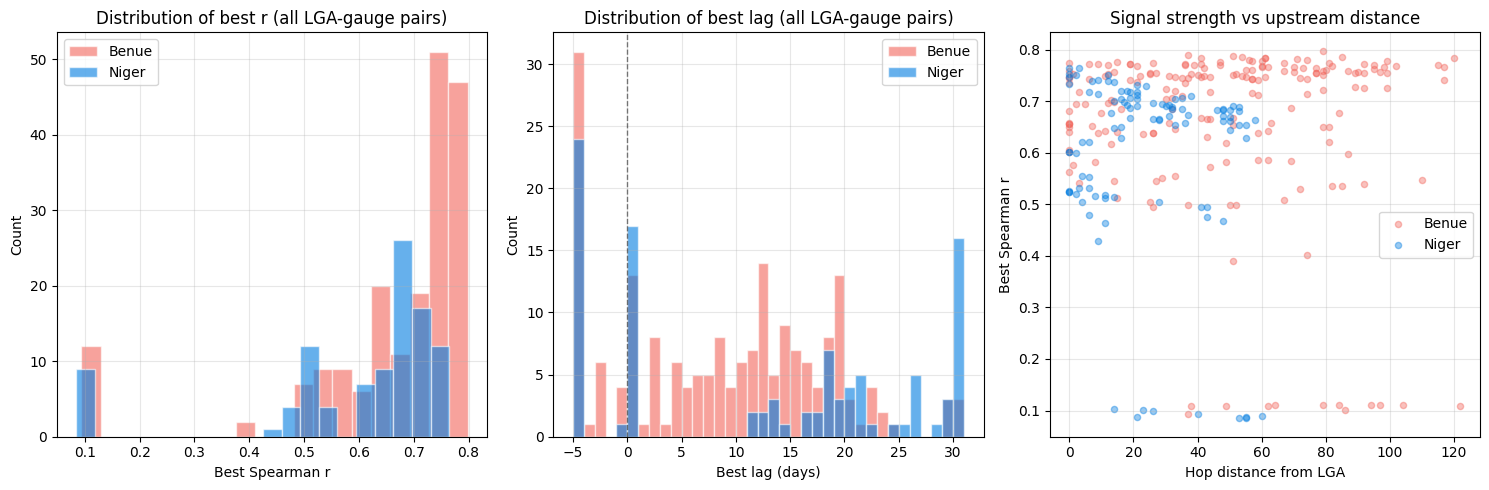

In [8]:
RIVER_COLORS = {"Niger": "#007CE0", "Benue": "#F2645A"}
DEFAULT_COLOR = "#666666"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Distribution of best r values by river
ax = axes[0]
for river, grp in df_corr_all.groupby("river"):
    color = RIVER_COLORS.get(river, DEFAULT_COLOR)
    ax.hist(grp["best_r"], bins=20, alpha=0.6, color=color, label=river, edgecolor="white")
ax.set_xlabel("Best Spearman r")
ax.set_ylabel("Count")
ax.set_title("Distribution of best r (all LGA-gauge pairs)")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Distribution of best lag values
ax = axes[1]
for river, grp in df_corr_all.groupby("river"):
    color = RIVER_COLORS.get(river, DEFAULT_COLOR)
    ax.hist(grp["best_lag"], bins=range(MIN_LAG, MAX_LAG + 2), alpha=0.6,
            color=color, label=river, edgecolor="white")
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Best lag (days)")
ax.set_ylabel("Count")
ax.set_title("Distribution of best lag (all LGA-gauge pairs)")
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Best r vs hop distance (scatter)
ax = axes[2]
for river, grp in df_corr_all.groupby("river"):
    color = RIVER_COLORS.get(river, DEFAULT_COLOR)
    ax.scatter(grp["hop_distance"], grp["best_r"],
               alpha=0.4, color=color, s=20, label=river)
ax.set_xlabel("Hop distance from LGA")
ax.set_ylabel("Best Spearman r")
ax.set_title("Signal strength vs upstream distance")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

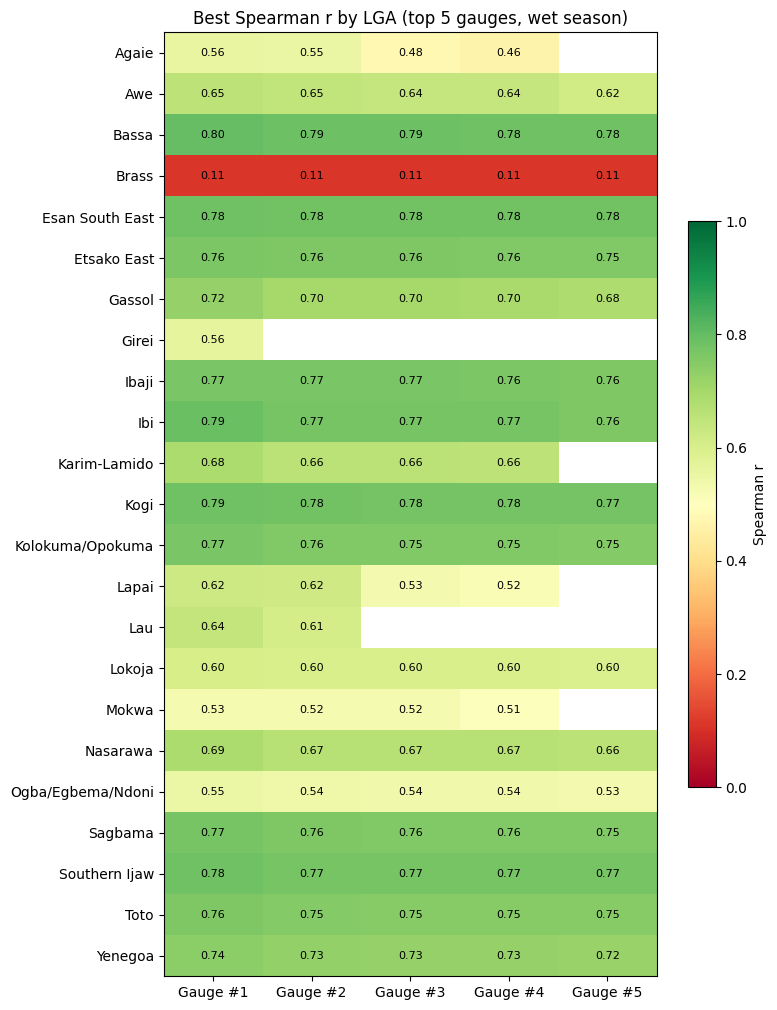

In [9]:
# Heatmap: best r per LGA for top N gauges per LGA (ordered by best_r)
# Pivot: rows = LGA, columns = gauge rank (1st, 2nd, 3rd best)
df_ranked = (
    df_corr_all.sort_values(["lga_pcode", "best_r"], ascending=[True, False])
    .assign(rank=lambda d: d.groupby("lga_pcode").cumcount() + 1)
)
df_pivot = df_ranked[df_ranked["rank"] <= 5].pivot(index="lga_name", columns="rank", values="best_r")
df_pivot.columns = [f"Gauge #{c}" for c in df_pivot.columns]

fig, ax = plt.subplots(figsize=(8, max(5, len(df_pivot) * 0.4 + 1)))
im = ax.imshow(df_pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(len(df_pivot.columns)))
ax.set_xticklabels(df_pivot.columns)
ax.set_yticks(range(len(df_pivot.index)))
ax.set_yticklabels(df_pivot.index)

# Annotate cells
for i in range(len(df_pivot.index)):
    for j in range(len(df_pivot.columns)):
        val = df_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Best Spearman r by LGA (top 5 gauges, wet season)")
plt.colorbar(im, ax=ax, label="Spearman r", shrink=0.6)
plt.tight_layout()
plt.show()

## Save to Azure

In [10]:
stratus.upload_parquet_to_blob(
    df_corr_all,
    "ds-aa-nga-flooding/processed/gauge_lga_correlations.parquet"
)
print(f"Saved gauge_lga_correlations.parquet ({len(df_corr_all)} rows)")

Saved gauge_lga_correlations.parquet (294 rows)
